In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
dataset = pd.read_csv("diabetes.csv")
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
dataset.isnull().sum()

,0
Pregnancies,2953.000
Glucose,92847.000
BloodPressure,53073.000
SkinThickness,15772.000
Insulin,61286.000
BMI,24570.300
DiabetesPedigreeFunction,362.401
Age,25529.000
Outcome,268.000


In [ ]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Text(0.5, 1.0, 'Correlation heatmap')

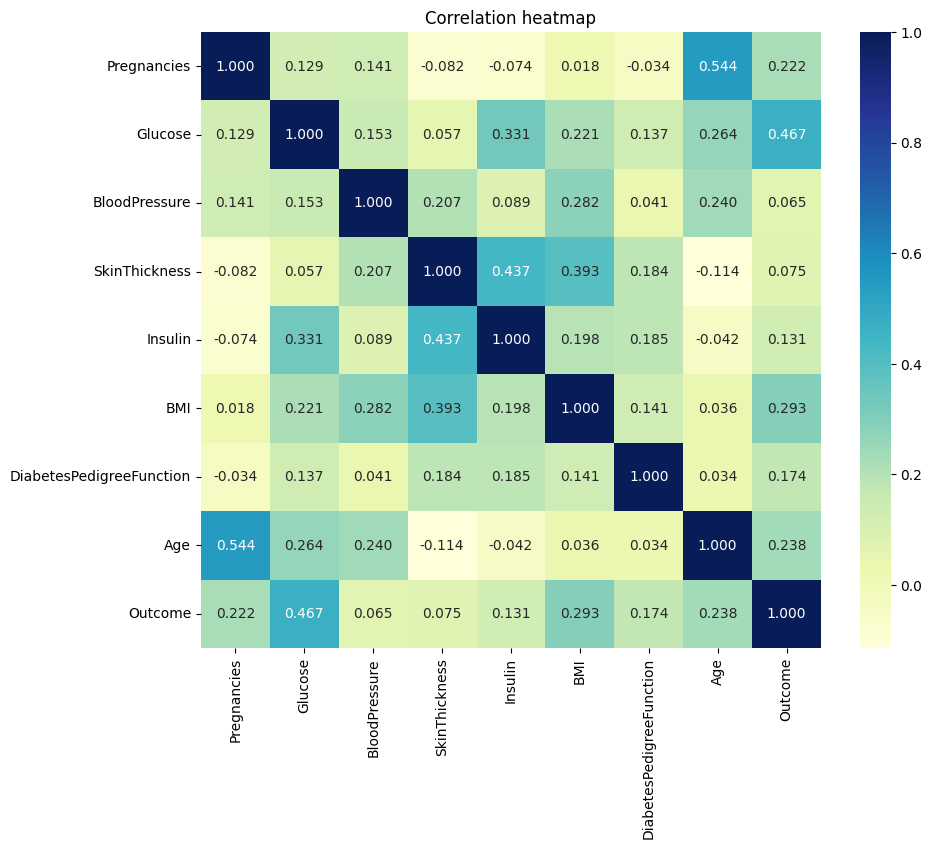

In [11]:
plt.figure(figsize = (10,8))
sns.heatmap(dataset.corr(), annot = True, fmt=".3f", cmap="YlGnBu")
plt.title("Correlation heatmap")

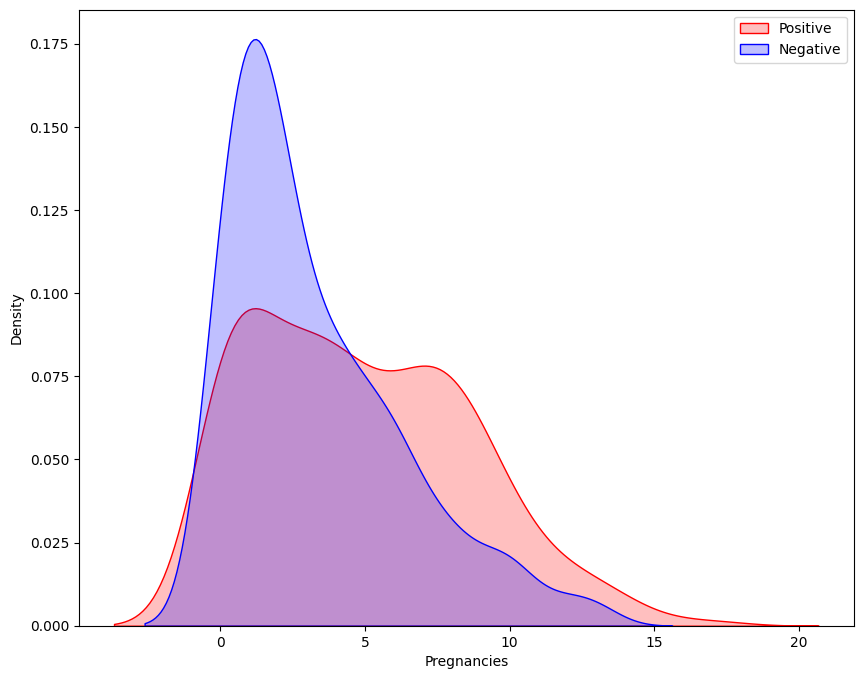

In [15]:
plt.figure(figsize = (10,8))
kde = sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==1], color="Red", fill = True)
kde = sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==0], color="Blue", fill = True)
kde.set_xlabel("Pregnancies")
kde.set_ylabel("Density")
kde.legend(["Positive", "Negative"])

<Axes: xlabel='Outcome', ylabel='Glucose'>

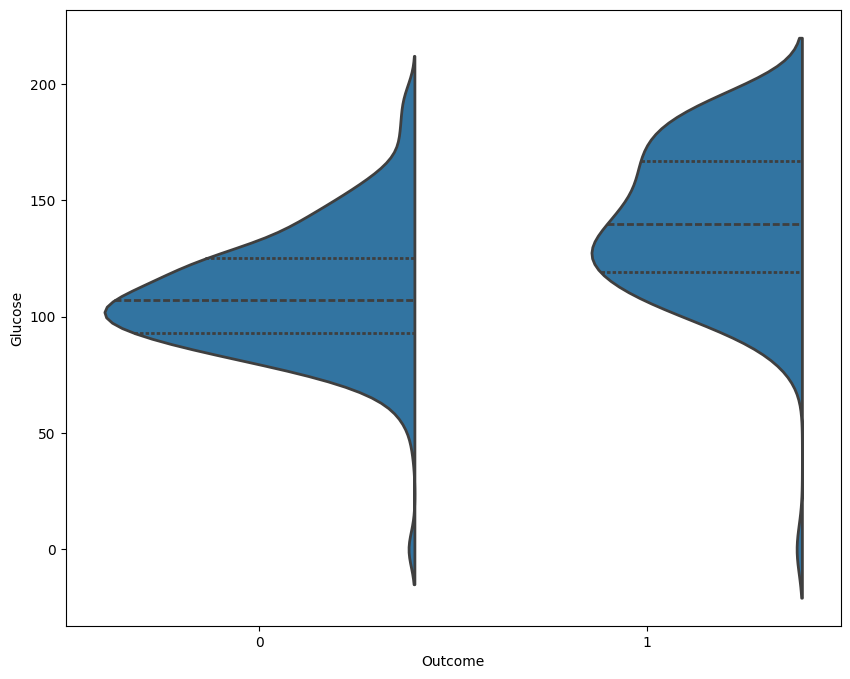

In [16]:
plt.figure(figsize =(10,8))
sns.violinplot(data=dataset, x="Outcome", y="Glucose", split=True, linewidth=2, inner="quart")

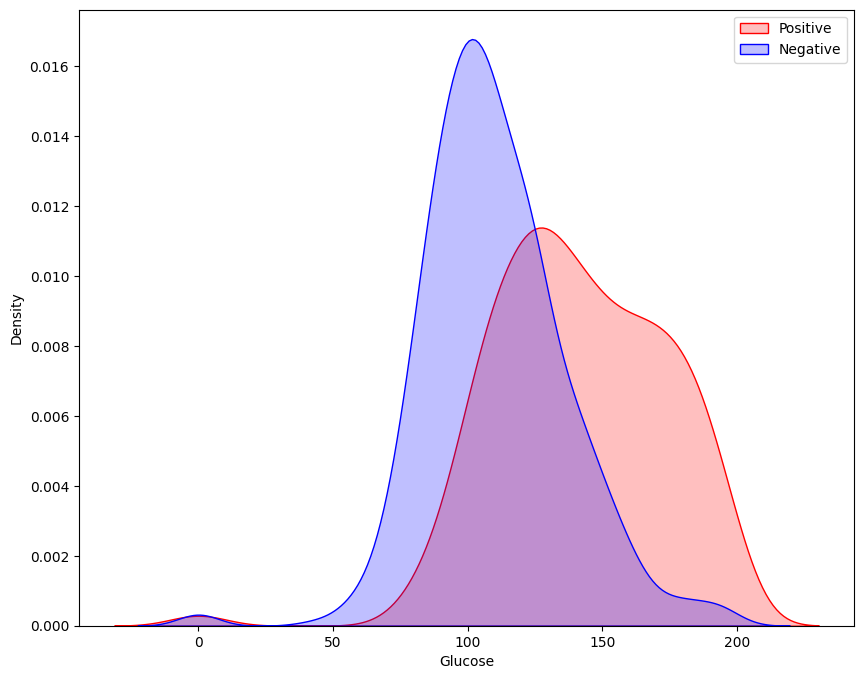

In [17]:
plt.figure(figsize = (10,8))
kde = sns.kdeplot(dataset["Glucose"][dataset["Outcome"]==1], color="Red", fill = True)
kde = sns.kdeplot(dataset["Glucose"][dataset["Outcome"]==0], color="Blue", fill = True)
kde.set_xlabel("Glucose")
kde.set_ylabel("Density")
kde.legend(["Positive", "Negative"])

In [21]:
dataset["Glucose"] = dataset["Glucose"].replace(0, dataset["Glucose"].median())
dataset["BloodPressure"] = dataset["BloodPressure"].replace(0, dataset["BloodPressure"].median())
dataset["BMI"] = dataset["BMI"].replace(0, dataset["BMI"].mean())
dataset["SkinThickness"] = dataset["SkinThickness"].replace(0, dataset["SkinThickness"].mean())
dataset["Insulin"] = dataset["Insulin"].replace(0, dataset["Insulin"].mean())

In [22]:
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1


In [24]:
X = dataset.drop(["Outcome"], axis=1)
y = dataset["Outcome"]

In [25]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,30.5,33.6,0.627,50
1,1,85,66,29,30.5,26.6,0.351,31
2,8,183,64,23,30.5,23.3,0.672,32
3,1,89,66,23,94.0,28.1,0.167,21
4,0,137,40,35,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63
764,2,122,70,27,30.5,36.8,0.340,27
765,5,121,72,23,112.0,26.2,0.245,30
766,1,126,60,23,30.5,30.1,0.349,47


In [26]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [28]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [31]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
464,10,115,98,23,30.5,24.0,1.022,34
223,7,142,60,33,190.0,28.8,0.687,61
393,4,116,72,12,87.0,22.1,0.463,37
766,1,126,60,23,30.5,30.1,0.349,47
570,3,78,70,23,30.5,32.5,0.270,39
...,...,...,...,...,...,...,...,...
71,5,139,64,35,140.0,28.6,0.411,26
106,1,96,122,23,30.5,22.4,0.207,27
270,10,101,86,37,30.5,45.6,1.136,38
435,0,141,72,23,30.5,42.4,0.205,29


In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
training_accuracy = []
test_accuracy = []
for n_neighbours in range(1, 11):
  knn = KNeighborsClassifier(n_neighbors=n_neighbours)
  knn.fit(X_train, y_train)

  training_accuracy.append(knn.score(X_train, y_train))
  test_accuracy.append(knn.score(X_test, y_test))

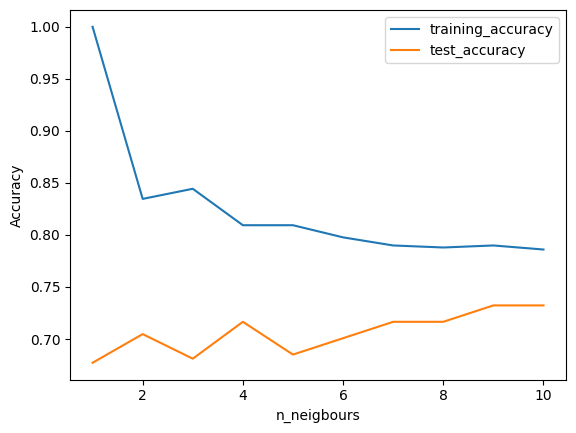

In [34]:
plt.plot(range(1,11), training_accuracy, label = "training_accuracy")
plt.plot(range(1,11), test_accuracy, label = "test_accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neigbours")
plt.legend()

In [36]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
print(knn.score(X_train, y_train), ": Training accuracy")
print(knn.score(X_test, y_test), ": Test accuracy")

0.7898832684824902 : Training accuracy
0.7322834645669292 : Test accuracy


In [37]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)
print(dt.score(X_train, y_train), ": Training accuracy")
print(dt.score(X_test, y_test), ": Test accuracy")

1.0 : Training accuracy
0.6929133858267716 : Test accuracy


In [39]:
dt1 = DecisionTreeClassifier(random_state=0, max_depth=3)
dt1.fit(X_train, y_train)
print(dt1.score(X_train, y_train), ": Training accuracy")
print(dt1.score(X_test, y_test), ": Test accuracy")

0.77431906614786 : Training accuracy
0.6929133858267716 : Test accuracy


In [40]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state = 42)
mlp.fit(X_train, y_train)
print(mlp.score(X_train, y_train), ": Training accuracy")
print(mlp.score(X_test, y_test), ": Test accuracy")

0.7645914396887159 : Training accuracy
0.7047244094488189 : Test accuracy


In [41]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.fit_transform(X_test)

In [46]:
mlp1 = MLPClassifier(random_state=0)
mlp1.fit(X_train_scaled, y_train)

print(mlp1.score(X_train_scaled, y_train), ": Training accuracy")
print(mlp1.score(X_test_scaled, y_test), ": Test accuracy")

0.8365758754863813 : Training accuracy
0.7283464566929134 : Test accuracy


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
